# Gravitational Wave Chirp Dataset Generator

This notebook generates synthetic gravitational wave chirp time series and saves them
in the same pickle format as `dataset_ts_no_anomaly_medium.pkl`.

Each sample is a dict with keys:
- `series_id`: integer index
- `unique_id`: string identifier
- `category`: category label
- `name`: signal type name
- `anomaly_info`: anomaly description
- `source_path`: source path string
- `data`: pandas Series (length 600, DatetimeIndex named 'time', values named 'value')

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Load reference dataset to confirm format

In [2]:
with open('dataset_ts_no_anomaly_medium.pkl', 'rb') as f:
    ref_data = pickle.load(f)

print(f"Reference dataset: {len(ref_data)} samples")
print(f"Series length: {len(ref_data[0]['data'])}")
print(f"Keys: {list(ref_data[0].keys())}")
print(f"Index: {ref_data[0]['data'].index[:3]}")
print(f"Sample data:\n{ref_data[0]['data'].head()}")

Reference dataset: 150 samples
Series length: 600
Keys: ['series_id', 'unique_id', 'category', 'name', 'anomaly_info', 'source_path', 'data']
Index: DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03'], dtype='datetime64[ns]', name='time', freq=None)
Sample data:
time
2024-01-01    17.778547
2024-01-02    17.058991
2024-01-03    18.507158
2024-01-04    17.995628
2024-01-05    19.695471
Name: value, dtype: float64


## 2. Chirp generation function

A periodic signal whose period varies quadratically over time, plus additive Gaussian noise:

$$h(t) = A \cos\!\left(2\pi \int_0^t f(t')\,dt'\right) + \varepsilon(t), \qquad f(t) = f_0 + \alpha t + \beta t^2$$

In [3]:
N_POINTS = 600  # match reference dataset


def make_time_index(n=N_POINTS, start='2024-01-01', freq='D'):
    """Create a DatetimeIndex matching the reference dataset."""
    return pd.date_range(start=start, periods=n, freq=freq, name='time')


def quadratic_chirp(n=N_POINTS, f0=0.02, alpha=0.05, beta=0.08,
                    amplitude=1.0, noise_level=0.1, rng=None):
    """
    Periodic signal with quadratically varying instantaneous frequency and noise.

    f(t) = f0 + alpha * t + beta * t^2
    """
    if rng is None:
        rng = np.random.default_rng()
    t = np.linspace(0, 1, n)
    # Instantaneous phase = integral of 2*pi*f(t)
    phase = 2 * np.pi * (f0 * t + alpha * t**2 / 2 + beta * t**3 / 3)
    signal = amplitude * np.cos(phase)
    signal += noise_level * amplitude * rng.standard_normal(n)
    return signal

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def generate_chirp(
    N: int = 600,
    t_end: float = 10.0,
    f0: float = 1.0,
    beta: float = 0.5,
    A: float = 1.0,
    sigma: float = 0.1,
    decay: bool = False,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Generate a chirp time series dataset.

    Returns
    -------
    pd.DataFrame with columns:
        t              — time axis
        y_clean        — noiseless chirp signal
        y              — noisy observed signal
        instantaneous_freq — f0 + beta*t at each point
    """
    rng = np.random.default_rng(seed)

    # Time axis
    t = np.linspace(0, t_end, N)

    # Instantaneous phase: φ(t) = 2π * (f0*t + 0.5*β*t²)
    phase = 2 * np.pi * (f0 * t + 0.5 * beta * t**2)

    # Amplitude envelope
    if decay:
        # Power-law decay mimicking GW inspiral amplitude growth then cutoff
        # Simple version: A grows as (1 + t)^(1/4) then you truncate
        amplitude = A * (1 + t) ** 0.25
    else:
        amplitude = A * np.ones_like(t)

    # Clean signal
    y_clean = amplitude * np.sin(phase)

    # Add noise
    noise = rng.normal(0, sigma, size=N)
    y = y_clean + noise

    # Instantaneous frequency at each point
    inst_freq = f0 + beta * t

    df = pd.DataFrame({
        "t": t,
        "y_clean": y_clean,
        "y": y,
        "instantaneous_freq": inst_freq,
    })

    return df


def plot_chirp(df: pd.DataFrame, save_path: str = None):
    """Plot the chirp dataset with 3 panels: signal, clean vs noisy, inst. frequency."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 8))
    fig.suptitle("Chirp Dataset — 600 Points", fontsize=14, fontweight="bold")

    # Panel 1: Noisy observed signal
    axes[0].plot(df["t"], df["y"], color="#4a90d9", linewidth=0.8, alpha=0.85)
    axes[0].set_ylabel("y (observed)")
    axes[0].set_title("Observed Signal (with noise)")
    axes[0].grid(True, alpha=0.3)

    # Panel 2: Clean signal overlay
    axes[1].plot(df["t"], df["y"], color="#4a90d9", linewidth=0.6,
                 alpha=0.5, label="Noisy")
    axes[1].plot(df["t"], df["y_clean"], color="#e05c5c", linewidth=1.2,
                 label="Clean")
    axes[1].set_ylabel("y")
    axes[1].set_title("Clean vs Noisy")
    axes[1].legend(loc="upper left")
    axes[1].grid(True, alpha=0.3)

    # Panel 3: Instantaneous frequency
    axes[2].plot(df["t"], df["instantaneous_freq"], color="#5cb85c", linewidth=1.5)
    axes[2].set_ylabel("Freq (Hz)")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Instantaneous Frequency  f(t) = f₀ + β·t")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Plot saved to: {save_path}")
    else:
        plt.show()

    return fig


Plot saved to: chirp_plot.png


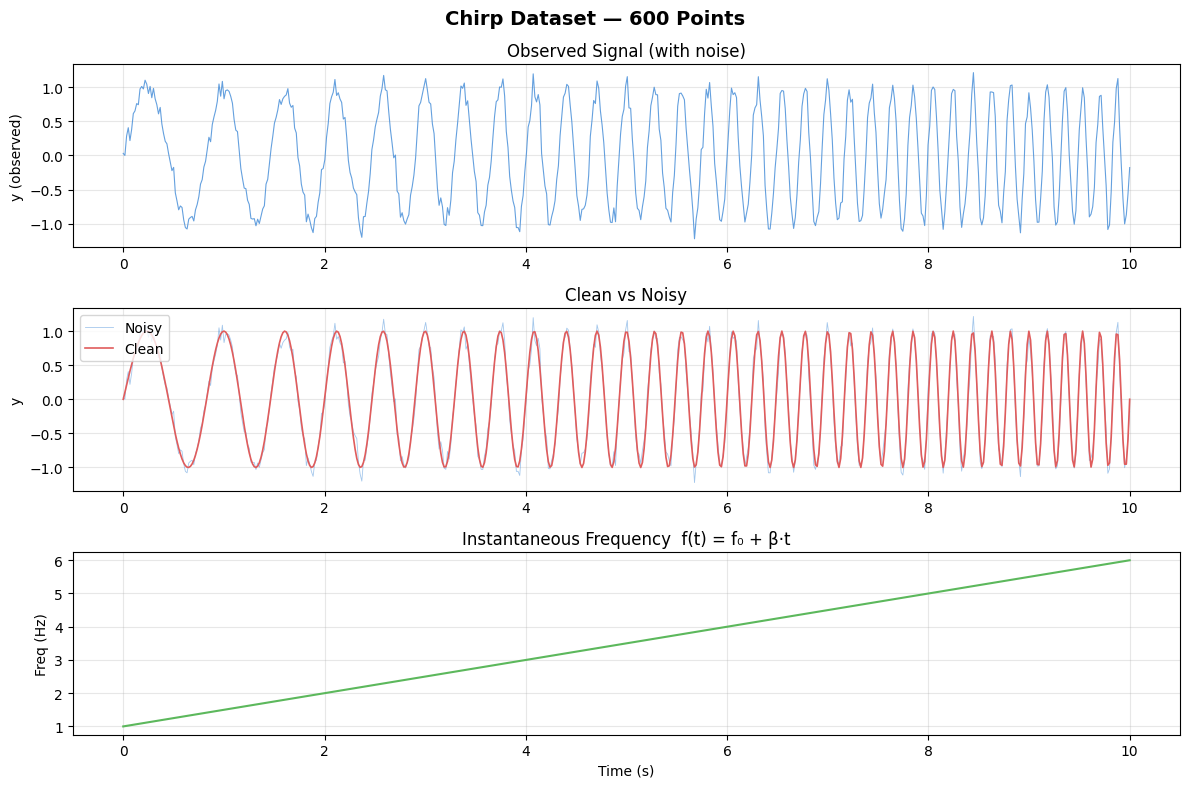

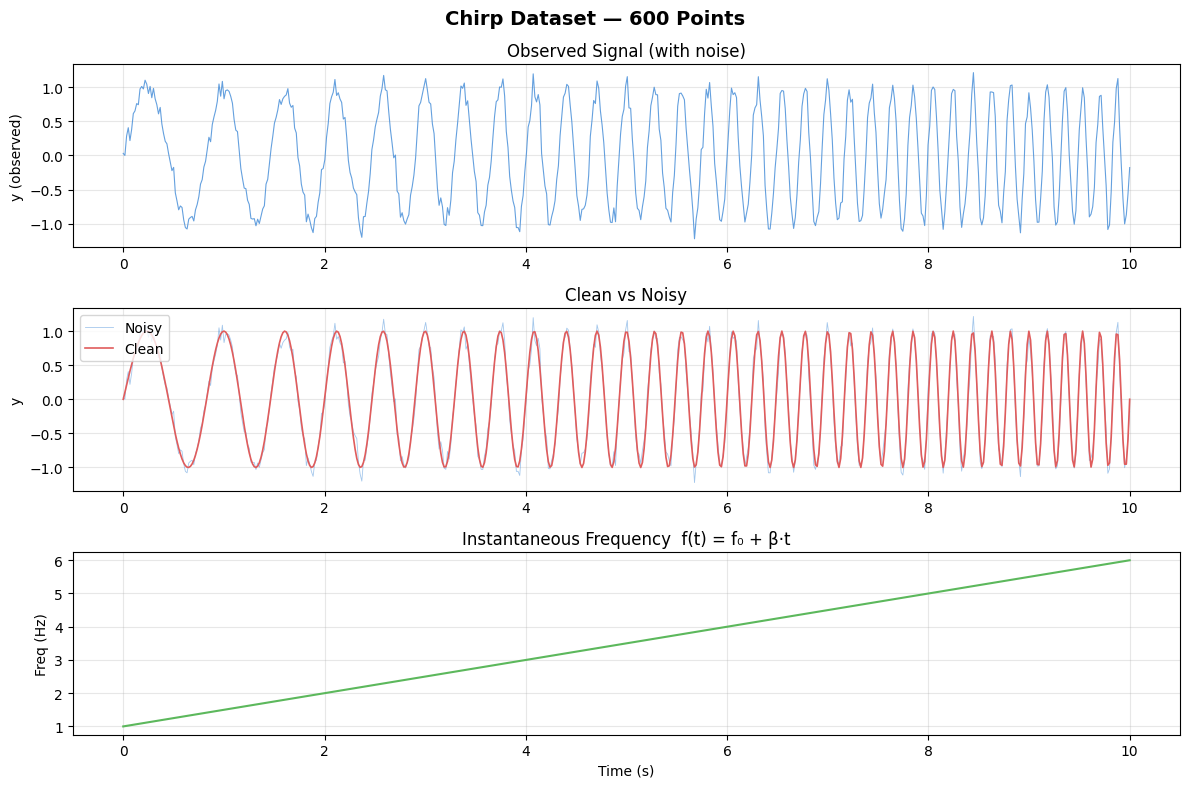

In [5]:
# Generate dataset
df = generate_chirp(
    N=600,
    t_end=10.0,
    f0=1.0,       # starts at 1 Hz
    beta=0.5,    # frequency grows 0.5 Hz every second → 6 Hz at t=10
    A=1.0,
    sigma=0.1,
    decay=False,
    seed=42,
)

# Plot
plot_chirp(df, save_path="chirp_plot.png")

## 3. Generate a small sample dataset

In [6]:
N_SAMPLES = 3
N_POINTS = 600

# 3 samples with different chirp parameters using generate_chirp
SAMPLE_PARAMS = [
    {'N': 600, 't_end': 10.0, 'f0': 1.0, 'beta': 0.5, 'A': 1.0, 'sigma': 0.1, 'decay': False, 'seed': 42},
    {'N': 600, 't_end': 10.0, 'f0': 0.5, 'beta': 0.8, 'A': 1.5, 'sigma': 0.15, 'decay': False, 'seed': 123},
    {'N': 600, 't_end': 10.0, 'f0': 2.0, 'beta': 0.3, 'A': 0.8, 'sigma': 0.08, 'decay': False, 'seed': 7},
]

time_index = pd.date_range(start='2024-01-01', periods=N_POINTS, freq='D', name='time')
dataset = []

for i, params in enumerate(SAMPLE_PARAMS):
    df = generate_chirp(**params)
    series = pd.Series(data=df['y'].values, index=time_index, name='value', dtype=np.float64)
    dataset.append({
        'series_id': i,
        'unique_id': f'gw_chirp_s{i:03d}',
        'category': 'GravitationalWave',
        'name': 'QuadraticChirp',
        'anomaly_info': 'No anomalies',
        'source_path': 'generated/gravitational_chirp_dataset',
        'data': series,
    })

print(f"Generated {len(dataset)} samples")
print(f"Series length: {len(dataset[0]['data'])}")

Generated 3 samples
Series length: 600


## (Testing) Warped Periodic GP (MAP)

A standard periodic kernel is stationary, so it cannot directly capture a chirp whose period changes over time.

We fix this by warping input time:

$$x_{\text{warp}} = a x + b x^2$$

and then applying a standard periodic kernel in warped space.

This keeps your same modeling pattern (`pm.gp.Marginal`, `find_MAP`, `predict`) while allowing nonstationary periodic behavior in original time.

In [7]:
import pymc as pm
import pytensor.tensor as pt


def _init_warp_from_zero_crossings(y_c: np.ndarray) -> tuple[float, float]:
    """Estimate (warp_a, warp_b) from cumulative zero crossings of centered y.

    Cumulative crossings up to normalized time x ≈ 2 * (a*x + b*x^2).
    We regress cum_crossings/2 on [x, x^2] with no intercept to get (a, b).
    """
    N = len(y_c)
    x = np.linspace(0.0, 1.0, N)
    crossings = (np.diff(np.sign(y_c)) != 0).astype(float)
    cum = np.concatenate([[0.0], np.cumsum(crossings)]) / 2.0  # cycles so far
    # Least squares: cum = a*x + b*x^2
    A = np.column_stack([x, x**2])
    coef, *_ = np.linalg.lstsq(A, cum, rcond=None)
    a_init, b_init = float(coef[0]), float(coef[1])
    # Fallback if regression gives nonsense
    total = max(cum[-1], 1.0)
    if not np.isfinite(a_init) or not np.isfinite(b_init):
        a_init, b_init = total, 0.0
    return a_init, b_init


def fit_warped_periodic_gp(data: pd.Series, t_end: float = 10.0):
    """Fit a periodic GP after quadratic input warping using MAP.

    Model
    -----
        x      = normalized time in [0, 1]
        x_warp = a * x + b * x^2
        y      ~ GP(0, eta^2 * Periodic(period=1, ls)) + Normal(0, sigma)

    The period is fixed at 1 to remove the (a, b, period) scale
    redundancy; all frequency information is absorbed into (a, b).
    (a, b) are initialized from a quadratic fit to the cumulative
    zero-crossing count, so the fit generalizes across chirps without
    tuning priors to specific truth values.
    """
    y = data.values.astype(float)
    y_mean = float(np.mean(y))
    y_c = y - y_mean
    y_std = float(np.std(y_c)) or 1.0
    N = len(y)

    x = np.linspace(0.0, 1.0, N, dtype=float)[:, None]

    a_init, b_init = _init_warp_from_zero_crossings(y_c)
    a_scale = max(0.3 * abs(a_init), 1.0)
    b_scale = max(0.3 * abs(b_init), 1.0)

    s = np.sign(data.values - np.mean(data.values))
    N_tot = int((np.diff(s) != 0).sum())
    N_half = int((np.diff(s[:len(s)//2]) != 0).sum())
    a_init = 2.0 * N_half - 0.5 * N_tot
    b_init = float(N_tot - 2.0 * N_half)

    with pm.Model() as model:
        warp_a = pm.Normal('warp_a', mu=a_init, sigma=a_scale)
        warp_b = pm.Normal('warp_b', mu=b_init, sigma=b_scale)

        X_t = pt.as_tensor_variable(x)
        X_warp = warp_a * X_t + warp_b * X_t**2

        amp = pm.HalfNormal('amp', sigma=2.0)
        ls = pm.HalfNormal('ls', sigma=1.0)

        sigma = pm.Exponential('sigma', 1)

        # period fixed at 1 — identifiable with free (warp_a, warp_b)
        cov = (amp**2) * pm.gp.cov.Periodic(input_dim=1, period=1.0, ls=ls)
        gp = pm.gp.Marginal(cov_func=cov)
        gp.marginal_likelihood('y', X=X_warp, y=y_c, sigma=sigma)

        map_start = {
            'warp_a': a_init,
            'warp_b': b_init,
            # 'amp': y_std,
            # 'ls': 0.5,
            # 'sigma': 0.3 * y_std,
        }
        map_estimate = pm.find_MAP(start=map_start, include_transformed=True, progressbar=False)

        mu, var = gp.predict(Xnew=X_warp, point=map_estimate, diag=True)

    trend = pd.Series(mu.flatten() + y_mean, index=data.index, name='trend')
    pred_std = pd.Series(np.sqrt(var), index=data.index, name='pred_std')
    return trend, pred_std, map_estimate


In [8]:
# Fit on one generated chirp series
series_for_fit = dataset[2]['data']
trend, pred_std, map_estimate = fit_warped_periodic_gp(series_for_fit)

print('MAP fit completed.')
print(f"Data points: {len(series_for_fit)}")

MAP fit completed.
Data points: 600


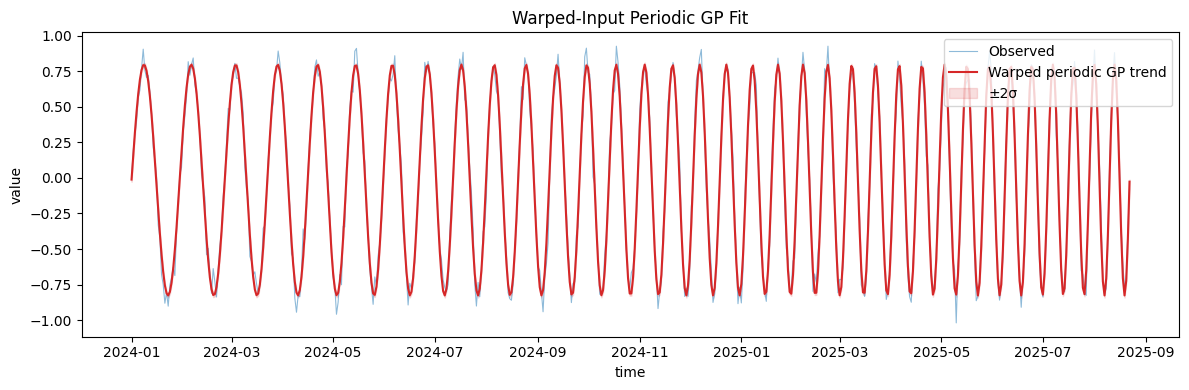

In [9]:
# Plot fit in original time index
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series_for_fit.index, series_for_fit.values, color='tab:blue', alpha=0.5, linewidth=0.8, label='Observed')
ax.plot(trend.index, trend.values, color='tab:red', linewidth=1.5, label='Warped periodic GP trend')
ax.fill_between(
    trend.index,
    trend.values - 2.0 * pred_std.values,
    trend.values + 2.0 * pred_std.values,
    color='tab:red',
    alpha=0.15,
    label='±2σ',
)
ax.set_title('Warped-Input Periodic GP Fit')
ax.set_xlabel('time')
ax.set_ylabel('value')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [10]:
# Fit all 3 chirp samples — verifies the fit generalizes without re-tuning priors
trends = []
for i, sample in enumerate(dataset):
    tr_i, sd_i, map_i = fit_warped_periodic_gp(sample['data'])
    trends.append({'series_id': i, 'trend': tr_i, 'pred_std': sd_i, 'map': map_i})
    a = float(np.asarray(map_i['warp_a']))
    b = float(np.asarray(map_i['warp_b']))
    params = SAMPLE_PARAMS[i]
    # True warp in normalized time: phi/2pi = t_end*f0*x + 0.5*t_end^2*beta*x^2
    a_true = params['t_end'] * params['f0']
    b_true = 0.5 * params['t_end']**2 * params['beta']
    print(f"sample {i}: warp_a={a:7.3f} (true {a_true:6.2f}), "
          f"warp_b={b:7.3f} (true {b_true:6.2f})")

sample 0: warp_a= 10.010 (true  10.00), warp_b= 24.994 (true  25.00)
sample 1: warp_a=  4.981 (true   5.00), warp_b= 40.022 (true  40.00)
sample 2: warp_a= 20.008 (true  20.00), warp_b= 14.989 (true  15.00)


## (Full Dataset) 50-sample dataset (40 standard chirps + 10 with amplitude decay)

Overwrites `dataset_ts_gravitational_chirp_50.pkl` with 50 samples:
- 40 standard chirps with programmatically randomized `f0`, `beta`, `A`, `sigma`, `seed`.
- 10 chirps with an exponential amplitude-decay envelope `exp(-t/tau)` applied on top of `generate_chirp`. This tests whether the warped-periodic GP still fits when the oscillation dies down over the window.

In [18]:
# # Manual implementation of dataset generation with more varied parameters for 15 samples, plus 5 with amplitude decay.
# STANDARD_PARAMS_15 = [
#     {'N': 600, 't_end': 10.0, 'f0': 1.0, 'beta': 0.50, 'A': 1.0,  'sigma': 0.10, 'decay': False, 'seed': 42},
#     {'N': 600, 't_end': 10.0, 'f0': 0.5, 'beta': 0.80, 'A': 1.5,  'sigma': 0.15, 'decay': False, 'seed': 123},
#     {'N': 600, 't_end': 10.0, 'f0': 2.0, 'beta': 0.30, 'A': 0.8,  'sigma': 0.08, 'decay': False, 'seed': 7},
#     {'N': 600, 't_end': 10.0, 'f0': 1.5, 'beta': 0.40, 'A': 1.2,  'sigma': 0.12, 'decay': False, 'seed': 11},
#     {'N': 600, 't_end': 10.0, 'f0': 0.8, 'beta': 0.60, 'A': 1.0,  'sigma': 0.10, 'decay': False, 'seed': 19},
#     {'N': 600, 't_end': 10.0, 'f0': 1.2, 'beta': 0.70, 'A': 1.1,  'sigma': 0.13, 'decay': False, 'seed': 27},
#     {'N': 600, 't_end': 10.0, 'f0': 0.3, 'beta': 1.00, 'A': 1.3,  'sigma': 0.15, 'decay': False, 'seed': 33},
#     {'N': 600, 't_end': 10.0, 'f0': 2.5, 'beta': 0.20, 'A': 0.7,  'sigma': 0.07, 'decay': False, 'seed': 41},
#     {'N': 600, 't_end': 10.0, 'f0': 1.8, 'beta': 0.50, 'A': 0.9,  'sigma': 0.11, 'decay': False, 'seed': 53},
#     {'N': 600, 't_end': 10.0, 'f0': 0.6, 'beta': 0.90, 'A': 1.4,  'sigma': 0.14, 'decay': False, 'seed': 67},
#     {'N': 600, 't_end': 10.0, 'f0': 1.0, 'beta': 0.30, 'A': 1.0,  'sigma': 0.09, 'decay': False, 'seed': 71},
#     {'N': 600, 't_end': 10.0, 'f0': 2.2, 'beta': 0.25, 'A': 0.85, 'sigma': 0.08, 'decay': False, 'seed': 83},
#     {'N': 600, 't_end': 10.0, 'f0': 0.9, 'beta': 0.55, 'A': 1.15, 'sigma': 0.12, 'decay': False, 'seed': 97},
#     {'N': 600, 't_end': 10.0, 'f0': 1.4, 'beta': 0.60, 'A': 1.0,  'sigma': 0.10, 'decay': False, 'seed': 103},
#     {'N': 600, 't_end': 10.0, 'f0': 0.7, 'beta': 0.70, 'A': 1.2,  'sigma': 0.12, 'decay': False, 'seed': 113},
# ]

# # Amplitude decay variants: y *= exp(-t / tau).  tau in [2.5, 4.5] gives visible decay over t_end=10.
# DECAY_PARAMS_5 = [
#     {'N': 600, 't_end': 10.0, 'f0': 1.0, 'beta': 0.50, 'A': 1.5, 'sigma': 0.10, 'tau': 3.0, 'seed': 201},
#     {'N': 600, 't_end': 10.0, 'f0': 0.5, 'beta': 0.80, 'A': 1.8, 'sigma': 0.12, 'tau': 4.0, 'seed': 211},
#     {'N': 600, 't_end': 10.0, 'f0': 2.0, 'beta': 0.30, 'A': 1.3, 'sigma': 0.09, 'tau': 2.5, 'seed': 223},
#     {'N': 600, 't_end': 10.0, 'f0': 1.5, 'beta': 0.40, 'A': 1.6, 'sigma': 0.11, 'tau': 3.5, 'seed': 229},
#     {'N': 600, 't_end': 10.0, 'f0': 0.8, 'beta': 0.60, 'A': 1.4, 'sigma': 0.10, 'tau': 4.5, 'seed': 239},
# ]

# N_POINTS_EXT = 600
# time_index_ext = pd.date_range(start='2024-01-01', periods=N_POINTS_EXT, freq='D', name='time')
# dataset_ext = []

# # 15 standard chirps
# for i, params in enumerate(STANDARD_PARAMS_15):
#     df_i = generate_chirp(**params)
#     y_vals = df_i['y'].values
#     series = pd.Series(data=y_vals, index=time_index_ext, name='value', dtype=np.float64)
#     dataset_ext.append({
#         'series_id': i,
#         'unique_id': f'gw_chirp_std_s{i:03d}',
#         'category': 'GravitationalWave',
#         'name': 'QuadraticChirp',
#         'anomaly_info': 'No anomalies',
#         'source_path': 'generated/gravitational_chirp_dataset_extended',
#         'data': series,
#     })

# # 5 amplitude-decay chirps: apply exp(-t/tau) envelope after generate_chirp
# for j, params in enumerate(DECAY_PARAMS_5):
#     tau = params.pop('tau')
#     df_i = generate_chirp(**params)
#     t_arr = df_i['t'].values
#     envelope = np.exp(-t_arr / tau)
#     y_clean_decay = df_i['y_clean'].values * envelope
#     # Re-add noise at the original sigma (noise amplitude stays constant, not decayed)
#     rng_d = np.random.default_rng(params['seed'] + 1000)
#     y_decay = y_clean_decay + rng_d.normal(0, params['sigma'], size=len(t_arr))
#     series = pd.Series(data=y_decay, index=time_index_ext, name='value', dtype=np.float64)
#     idx = len(STANDARD_PARAMS_15) + j
#     dataset_ext.append({
#         'series_id': idx,
#         'unique_id': f'gw_chirp_decay_s{idx:03d}',
#         'category': 'GravitationalWave',
#         'name': 'QuadraticChirpDecay',
#         'anomaly_info': 'No anomalies',
#         'source_path': 'generated/gravitational_chirp_dataset_extended',
#         'data': series,
#     })

# print(f"Generated {len(dataset_ext)} samples total "
#       f"({len(STANDARD_PARAMS_15)} standard + {len(DECAY_PARAMS_5)} amplitude-decay)")
# print(f"Series length: {len(dataset_ext[0]['data'])}")
# print(f"First decay sample name: {dataset_ext[15]['name']}")

In [14]:
# Programmatically generate 40 standard + 10 amplitude-decay chirp series
rng_params = np.random.default_rng(seed=777)

N_STANDARD = 40
N_DECAY = 10
N_POINTS_GEN = 600
T_END = 10.0

# --- Parameter ranges ---
f0_range = (0.3, 2.5)
beta_range = (0.20, 1.00)
A_range = (0.7, 1.8)
sigma_range = (0.07, 0.15)
tau_range = (2.0, 5.0)

# Generate unique seeds
all_seeds = rng_params.choice(range(1, 10000), size=N_STANDARD + N_DECAY, replace=False)

# --- 40 standard chirp param sets ---
std_params_40 = []
for i in range(N_STANDARD):
    std_params_40.append({
        'N': N_POINTS_GEN,
        't_end': T_END,
        'f0': round(float(rng_params.uniform(*f0_range)), 2),
        'beta': round(float(rng_params.uniform(*beta_range)), 2),
        'A': round(float(rng_params.uniform(*A_range)), 2),
        'sigma': round(float(rng_params.uniform(*sigma_range)), 3),
        'decay': False,
        'seed': int(all_seeds[i]),
    })

# --- 10 amplitude-decay param sets ---
decay_params_10 = []
for j in range(N_DECAY):
    decay_params_10.append({
        'N': N_POINTS_GEN,
        't_end': T_END,
        'f0': round(float(rng_params.uniform(*f0_range)), 2),
        'beta': round(float(rng_params.uniform(*beta_range)), 2),
        'A': round(float(rng_params.uniform(*A_range)), 2),
        'sigma': round(float(rng_params.uniform(*sigma_range)), 3),
        'tau': round(float(rng_params.uniform(*tau_range)), 2),
        'seed': int(all_seeds[N_STANDARD + j]),
    })

# --- Build dataset ---
time_index_gen = pd.date_range(start='2024-01-01', periods=N_POINTS_GEN, freq='D', name='time')
dataset_gen = []

# Standard chirps
for i, params in enumerate(std_params_40):
    df_i = generate_chirp(**params)
    series = pd.Series(data=df_i['y'].values, index=time_index_gen, name='value', dtype=np.float64)
    dataset_gen.append({
        'series_id': i,
        'unique_id': f'gw_chirp_std_s{i:03d}',
        'category': 'GravitationalWave',
        'name': 'QuadraticChirp',
        'anomaly_info': 'No anomalies',
        'source_path': 'generated/gravitational_chirp_dataset_v2',
        'data': series,
    })

# Amplitude-decay chirps
for j, params in enumerate(decay_params_10):
    tau = params.pop('tau')
    df_i = generate_chirp(**params)
    t_arr = df_i['t'].values
    envelope = np.exp(-t_arr / tau)
    y_clean_decay = df_i['y_clean'].values * envelope
    rng_d = np.random.default_rng(params['seed'] + 1000)
    y_decay = y_clean_decay + rng_d.normal(0, params['sigma'], size=len(t_arr))
    series = pd.Series(data=y_decay, index=time_index_gen, name='value', dtype=np.float64)
    idx = N_STANDARD + j
    dataset_gen.append({
        'series_id': idx,
        'unique_id': f'gw_chirp_decay_s{idx:03d}',
        'category': 'GravitationalWave',
        'name': 'QuadraticChirpDecay',
        'anomaly_info': 'No anomalies',
        'source_path': 'generated/gravitational_chirp_dataset_v2',
        'data': series,
    })

print(f"Generated {len(dataset_gen)} samples ({N_STANDARD} standard + {N_DECAY} decay)")
print(f"Series length: {len(dataset_gen[0]['data'])}")
print(f"Standard sample params example: {std_params_40[0]}")
print(f"Decay sample params example (tau restored): tau used for idx {N_STANDARD} = {decay_params_10[0]}")
print(f"Last sample: id={dataset_gen[-1]['series_id']}, name={dataset_gen[-1]['name']}")

Generated 50 samples (40 standard + 10 decay)
Series length: 600
Standard sample params example: {'N': 600, 't_end': 10.0, 'f0': 2.29, 'beta': 0.26, 'A': 1.59, 'sigma': 0.132, 'decay': False, 'seed': 1033}
Decay sample params example (tau restored): tau used for idx 40 = {'N': 600, 't_end': 10.0, 'f0': 1.12, 'beta': 0.85, 'A': 0.78, 'sigma': 0.117, 'seed': 4194}
Last sample: id=49, name=QuadraticChirpDecay


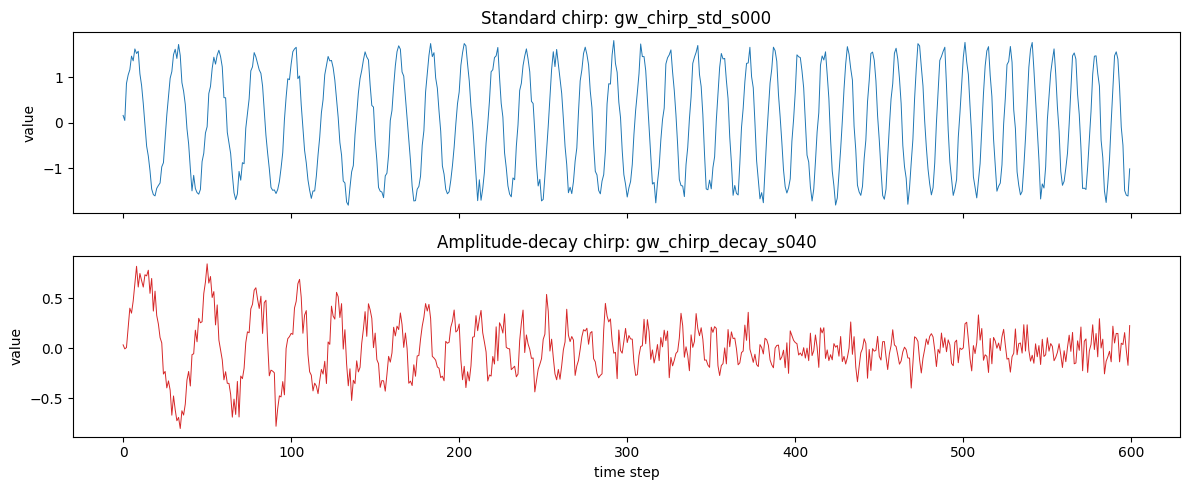

In [15]:
# Quick visual check: first standard + first decay sample side-by-side
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(np.arange(N_POINTS_GEN), dataset_gen[0]['data'].values, color='tab:blue', linewidth=0.7)
axes[0].set_title(f"Standard chirp: {dataset_gen[0]['unique_id']}")
axes[0].set_ylabel('value')
axes[1].plot(np.arange(N_POINTS_GEN), dataset_gen[N_STANDARD]['data'].values, color='tab:red', linewidth=0.7)
axes[1].set_title(f"Amplitude-decay chirp: {dataset_gen[N_STANDARD]['unique_id']}")
axes[1].set_xlabel('time step')
axes[1].set_ylabel('value')
plt.tight_layout()
plt.show()

In [17]:
# Overwrite dataset_gravitational_chirp.pkl with the 50-sample dataset
output_path_ext = 'dataset_ts_gravitational_chirp_50.pkl'
with open(output_path_ext, 'wb') as f:
    pickle.dump(dataset_gen, f)

print(f"Saved {len(dataset_gen)} samples to {output_path_ext}")
print(f"File size: {Path(output_path_ext).stat().st_size / 1024:.1f} KB")

# Verify against reference format
with open(output_path_ext, 'rb') as f:
    loaded_ext = pickle.load(f)
assert set(loaded_ext[0].keys()) == set(ref_data[0].keys()), 'key mismatch'
assert len(loaded_ext) == N_STANDARD + N_DECAY
assert loaded_ext[0]['data'].index.name == 'time'
assert loaded_ext[0]['data'].name == 'value'
print("Format verified against reference dataset.")

Saved 50 samples to dataset_ts_gravitational_chirp_50.pkl
File size: 487.9 KB
Format verified against reference dataset.
